MFCC shape: (13, 63)


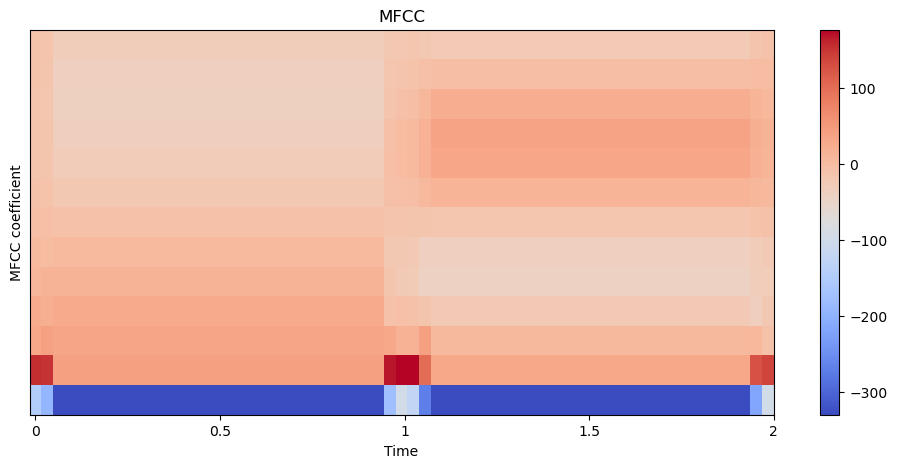

In [1]:
#Mel frequency cepstral coefficients

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

sample_rate = 16000
duration = 2.0

N = int(sample_rate * duration)
time = np.arange(N) / sample_rate

# Example signal
signal = np.zeros(N)

signal[:sample_rate] = np.sin(
    2 * np.pi * 300 * time[:sample_rate]
)

signal[sample_rate:] = np.sin(
    2 * np.pi * 700 * time[sample_rate:]
)

# Calculate MFCCs
mfcc = librosa.feature.mfcc(
    y=signal,
    sr=sample_rate,
    n_mfcc=13,
    n_fft=2048,
    hop_length=512,
    n_mels=80
)

print("MFCC shape:", mfcc.shape)

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mfcc,
    sr=sample_rate,
    hop_length=512,
    x_axis="time"
)

plt.colorbar()
plt.ylabel("MFCC coefficient")
plt.title("MFCC")

plt.show()

In [ ]:
# Let's make the pipeline explicit
# Instead of asking librosa for MFCCs directly, conceptually it does something like:
mel_spec = librosa.feature.melspectrogram(
    y=signal,
    sr=sample_rate,
    n_fft=2048,
    hop_length=512,
    n_mels=80
)

log_mel = librosa.power_to_db(
    mel_spec
)

mfcc = librosa.feature.mfcc(
    S=log_mel,
    n_mfcc=13
)

In [ ]:
"""
Yes. First, cepstral just means “related to the cepstrum.”
The cepstrum is obtained by taking a spectrum, applying a log, then transforming it again—classically with an inverse Fourier transform; in MFCCs, we use a DCT on the log-Mel spectrum.

“Cepstrum” is intentionally a play on the word “spectrum” with the first four letters reversed.
"""

Log-Mel shape: (80, 63)
MFCC shape: (13, 63)


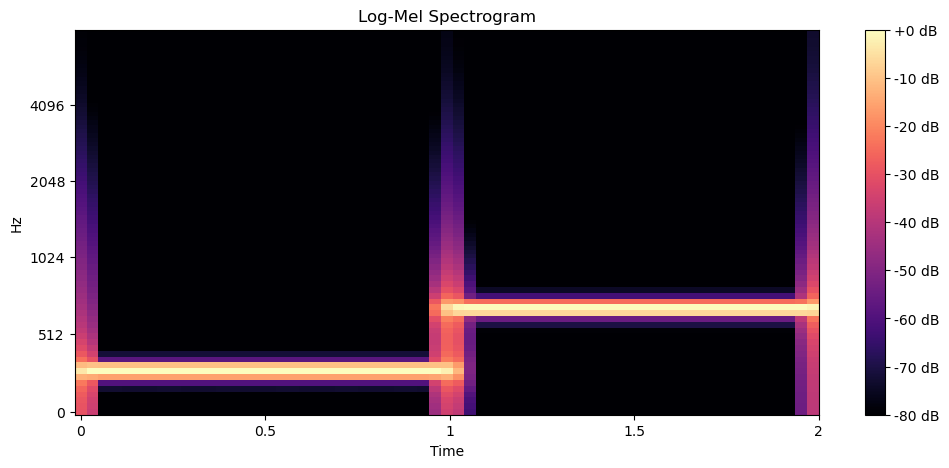

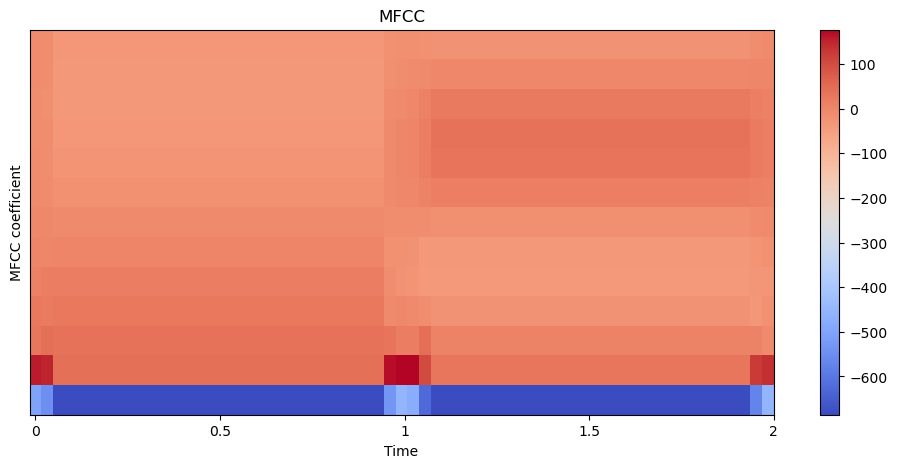

In [2]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

sample_rate = 16000
duration = 2.0

N = int(sample_rate * duration)
time = np.arange(N) / sample_rate

# --------------------------------------------------
# Create example signal
# 0-1 sec   -> 300 Hz
# 1-2 sec   -> 700 Hz
# --------------------------------------------------

signal = np.zeros(N)

signal[:sample_rate] = np.sin(
    2 * np.pi * 300 * time[:sample_rate]
)

signal[sample_rate:] = np.sin(
    2 * np.pi * 700 * time[sample_rate:]
)

# --------------------------------------------------
# Log-Mel Spectrogram
# --------------------------------------------------

mel_spectrogram = librosa.feature.melspectrogram(
    y=signal,
    sr=sample_rate,
    n_fft=2048,
    hop_length=512,
    win_length=2048,
    n_mels=80,
    power=2.0
)

log_mel = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max
)

# --------------------------------------------------
# MFCC
# --------------------------------------------------

mfcc = librosa.feature.mfcc(
    S=log_mel,
    n_mfcc=13
)

print("Log-Mel shape:", log_mel.shape)
print("MFCC shape:", mfcc.shape)

# --------------------------------------------------
# Plot Log-Mel
# --------------------------------------------------

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    log_mel,
    sr=sample_rate,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Log-Mel Spectrogram")
plt.show()

# --------------------------------------------------
# Plot MFCC
# --------------------------------------------------

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mfcc,
    sr=sample_rate,
    hop_length=512,
    x_axis="time"
)

plt.colorbar()
plt.ylabel("MFCC coefficient")
plt.title("MFCC")
plt.show()

In [ ]:
# The MFCC DCT transforms the Mel-frequency axis into a new coefficient domain, so after that transform, the rows no longer correspond directly to frequencies.